In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats

# Chargement des données nettoyées
df = pd.read_csv("../PRE/merged_cleaned.csv")

# Aperçu rapide
df.head()

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,Walc_por,health_por,absences_por,G1_por,G2_por,G3_por,grade_avg,alcohol_avg,abuse_alcohol,success
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,1,3,4,0,11,11,5.666667,1.0,False,False
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,1,3,2,9,11,11,5.333333,1.0,False,False
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,3,3,6,12,13,12,8.333333,2.5,False,False
3,GP,F,15,U,GT3,T,4,2,health,services,...,1,5,0,14,14,14,14.666667,1.0,False,True
4,GP,F,16,U,GT3,T,3,3,other,other,...,2,5,0,11,13,13,8.666667,1.5,False,False


Hypothèse 1 : La consommation d’alcool est-elle plus élevée chez les élèves dont les parents ont un faible niveau d’éducation ?
Hypothèse :
H₀ : La consommation d’alcool moyenne est identique quel que soit le niveau d’étude des parents.

H₁ : Elle est plus élevée quand le niveau d’étude des parents est faible.

On va regrouper les niveaux d’éducation en deux groupes :

Modeste (niveau 0, 1)

Élevé (niveau 2, 3, 4)

In [ ]:
# Recode du niveau d'instruction du père
df['low_edu_father'] = df['Fedu'] <= 2  # 0 à 2 = modeste

# Vérif rapide
print(df[['Fedu', 'low_edu_father']].head())

# Séparation des groupes
group1 = df[df['low_edu_father']]['alcohol_avg']
group2 = df[~df['low_edu_father']]['alcohol_avg']

# Test de Student (comparaison de deux moyennes)
t_stat, p_val = stats.ttest_ind(group1, group2, equal_var=False)
 
print(f"T-statistic = {t_stat:.4f}, p-value = {p_val:.4f}")
if p_val < 0.05:
    print("✅ Hypothèse validée : la consommation est significativement plus élevée chez les élèves dont le père a un faible niveau d'éducation.")
else:
    print("❌ Pas de différence significative.")

   Fedu  low_edu_father
0     4           False
1     1            True
2     1            True
3     2            True
4     3           False
T-statistic = 0.3239, p-value = 0.7462
❌ Pas de différence significative.


   Fedu  low_edu_father
0     4           False
1     1            True
2     1            True
3     2            True
4     3           False
T-statistic = 0.3239, p-value = 0.7462
❌ Pas de différence significative.


   Fedu  low_edu_father
0     4           False
1     1            True
2     1            True
3     2            True
4     3           False
T-statistic = 0.3239, p-value = 0.7462
❌ Pas de différence significative.


Hypothèse 2 : L’abus d’alcool a-t-il un impact significatif sur la réussite scolaire ?
Hypothèse :
H₀ : Le taux de réussite est indépendant de l’abus d’alcool.

H₁ : Les élèves qui abusent de l’alcool réussissent significativement moins souvent.

On va comparer deux proportions de réussite (success = True) :

Chez les élèves qui abusent de l’alcool (abuse_alcohol == True)

Chez ceux qui n’en abusent pas (abuse_alcohol == False)

In [18]:
# Table de contingence entre abus d'alcool et réussite
contingency = pd.crosstab(df['abuse_alcohol'], df['success'])

print("Table de contingence :\n", contingency)


# Test du chi²
chi2, p, _, _ = stats.chi2_contingency(contingency)

print(f"\nChi2 = {chi2:.4f}, p-value = {p:.4f}")

if p < 0.05:
    print("✅ Hypothèse validée : la réussite est liée à l’abus d’alcool.")
else:
    print("❌ Pas de lien significatif.")


Table de contingence :
 success        False  True 
abuse_alcohol              
False            145    199
True              18     20

Chi2 = 0.1974, p-value = 0.6569
❌ Pas de lien significatif.


C:\Users\geams\AppData\Local\Temp\ipykernel_25428\4261090697.py:6: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(x="abuse_alcohol", y="success", data=df, ci=None)


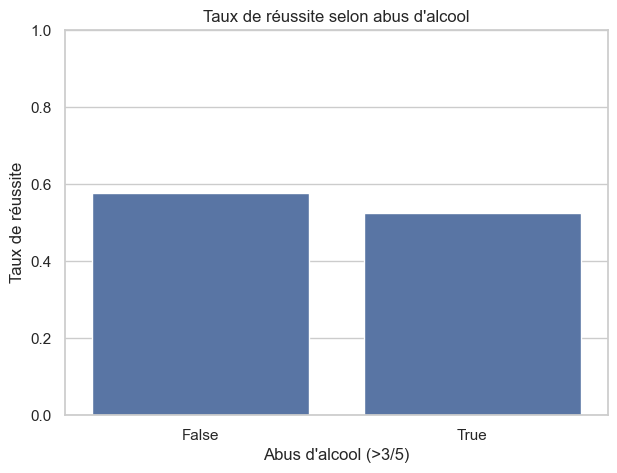

In [5]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.set(style="whitegrid")
plt.figure(figsize=(7,5))
sns.barplot(x="abuse_alcohol", y="success", data=df, ci=None)
plt.title("Taux de réussite selon abus d'alcool")
plt.xlabel("Abus d'alcool (>3/5)")
plt.ylabel("Taux de réussite")
plt.ylim(0, 1)
plt.show()

Hypothèse 3 : Les filles consomment-elles significativement moins d’alcool que les garçons ?
Hypothèse :
H₀ : Il n’y a pas de différence de consommation d’alcool moyenne entre les sexes.

H₁ : Les filles consomment en moyenne moins d’alcool que les garçons.

In [20]:
# Test : Test de Student sur la variable alcohol_avg

# Séparation des groupes
girls = df[df['sex'] == 'F']['alcohol_avg']
boys = df[df['sex'] == 'M']['alcohol_avg']

# Vérification des moyennes
print(f"Moyenne consommation - Filles : {girls.mean():.2f}")
print(f"Moyenne consommation - Garçons : {boys.mean():.2f}")

# Test de Student (2 échantillons indépendants)
t_stat, p_val = stats.ttest_ind(girls, boys, equal_var=False)

print(f"\nT-statistic = {t_stat:.4f}, p-value = {p_val:.4f}")
if p_val < 0.05 and girls.mean() < boys.mean():
    print("✅ Hypothèse validée : les filles consomment significativement moins d’alcool que les garçons.")
elif p_val < 0.05:
    print("⚠️ Différence significative, mais les filles ne consomment pas forcément moins.")
else:
    print("❌ Aucune différence significative entre les sexes.")


Moyenne consommation - Filles : 1.61
Moyenne consommation - Garçons : 2.16

T-statistic = -5.5338, p-value = 0.0000
✅ Hypothèse validée : les filles consomment significativement moins d’alcool que les garçons.


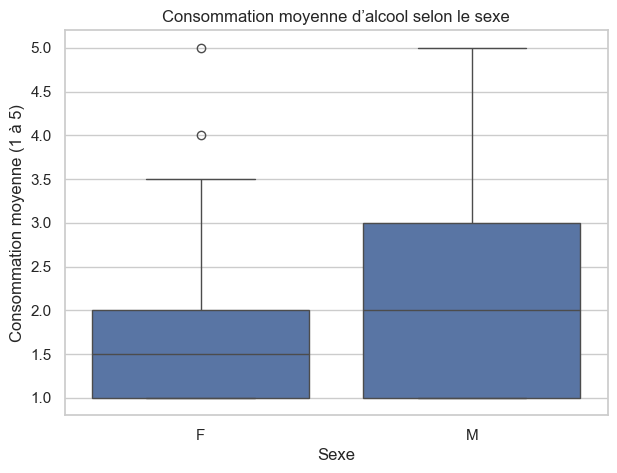

In [7]:
plt.figure(figsize=(7,5))
sns.boxplot(x="sex", y="alcohol_avg", data=df)
plt.title("Consommation moyenne d’alcool selon le sexe")
plt.xlabel("Sexe")
plt.ylabel("Consommation moyenne (1 à 5)")
plt.show()

Hypothèse 4 : La consommation d'alcool le week-end est-elle significativement plus élevée que celle en semaine ?
Hypothèses :

H₀ : La moyenne de consommation le week-end est égale à celle en semaine.

H₁ : Elle est significativement plus élevée le week-end.

T-statistic = 16.0857, p-value = 0.0000
✅ Hypothèse validée : la consommation est significativement plus élevée le week-end.


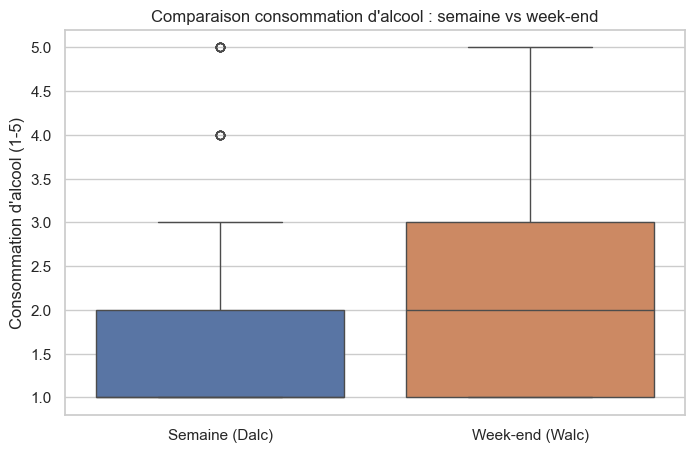

In [8]:
# Test de Student entre Walc (weekend) et Dalc (semaine)
t_stat, p_val = stats.ttest_rel(df["Walc_math"], df["Dalc_math"])

print(f"T-statistic = {t_stat:.4f}, p-value = {p_val:.4f}")
if p_val < 0.05:
    print("✅ Hypothèse validée : la consommation est significativement plus élevée le week-end.")
else:
    print("❌ Pas de différence significative.")

# Visualisation : comparaison des deux distributions
plt.figure(figsize=(8,5))
sns.boxplot(data=df[["Dalc_math", "Walc_math"]])
plt.xticks([0, 1], ["Semaine (Dalc)", "Week-end (Walc)"])
plt.ylabel("Consommation d'alcool (1-5)")
plt.title("Comparaison consommation d'alcool : semaine vs week-end")
plt.show()


Hypothèse 5 : Les étudiants vivant en milieu urbain consomment-ils moins d'alcool que ceux vivant en milieu rural ?
Hypothèses :
H₀ : Il n’y a pas de différence significative de consommation d’alcool selon le lieu de résidence.

H₁ : Les élèves en milieu rural consomment significativement plus que ceux en milieu urbain.

T-statistic = 2.1007, p-value = 0.0377
✅ Hypothèse validée : les élèves en milieu rural consomment significativement plus d’alcool.


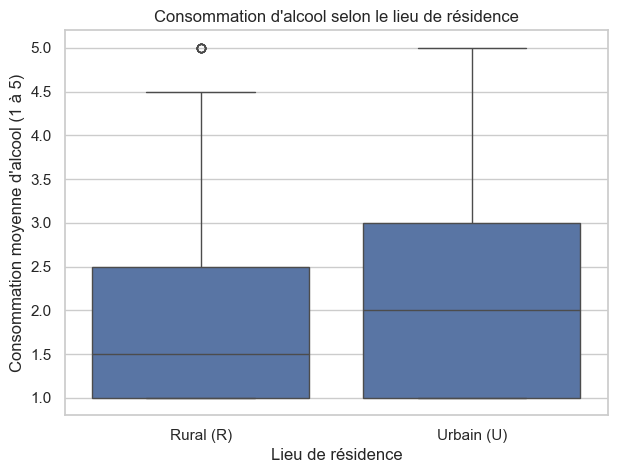

In [9]:
# Regrouper par type d'habitat
urban = df[df["address"] == "U"]["alcohol_avg"]
rural = df[df["address"] == "R"]["alcohol_avg"]

# Test de Student (deux échantillons indépendants)
t_stat, p_val = stats.ttest_ind(rural, urban, equal_var=False)

print(f"T-statistic = {t_stat:.4f}, p-value = {p_val:.4f}")
if p_val < 0.05:
    print("✅ Hypothèse validée : les élèves en milieu rural consomment significativement plus d’alcool.")
else:
    print("❌ Pas de différence significative.")

# Visualisation
plt.figure(figsize=(7,5))
sns.boxplot(x="address", y="alcohol_avg", data=df)
plt.xticks([0, 1], ["Rural (R)", "Urbain (U)"])
plt.title("Consommation d'alcool selon le lieu de résidence")
plt.ylabel("Consommation moyenne d'alcool (1 à 5)")
plt.xlabel("Lieu de résidence")
plt.show()


La consommation d’alcool est-elle liée au nombre d’absences scolaires ?

Analyse statistique : Calculer la corrélation entre consommation moyenne (alcohol_avg) et nombre d’absences (absences)

Visualisation : nuage de points avec une régression linéaire (scatterplot + lineaire fit)

Test : test de corrélation de Pearson (r, p-value)

Corrélation Pearson = 0.2156, p-value = 0.0000
✅ Hypothèse validée : la consommation d'alcool est significativement liée au nombre d'absences.


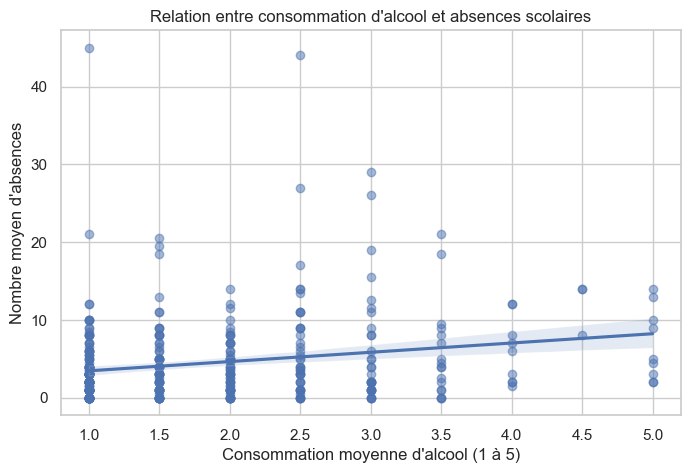

In [ ]:
# Création d'une colonne moyenne d'absences entre math et portugais
df['absences_avg'] = df[['absences_math', 'absences_por']].mean(axis=1)

# Calcul corrélation entre consommation moyenne d'alcool et absences moyennes
corr, p_val = stats.pearsonr(df['alcohol_avg'], df['absences_avg'])
print(f"Corrélation Pearson = {corr:.4f}, p-value = {p_val:.4f}")

if p_val < 0.05:
    print("✅ Hypothèse validée : la consommation d'alcool est significativement liée au nombre d'absences.")
else:
    print("❌ Pas de lien significatif.")

# Visualisation
plt.figure(figsize=(8,5))
sns.regplot(x='alcohol_avg', y='absences_avg', data=df, scatter_kws={'alpha':0.5})
plt.title("Relation entre consommation d'alcool et absences scolaires")
plt.xlabel("Consommation moyenne d'alcool (1 à 5)")
plt.ylabel("Nombre moyen d'absences")
plt.show()


Élèves ayant une activité extra-scolaire vs consommation d’alcool